Imports

In [ ]:
# @title
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

Exploring Dataframe

In [ ]:
import pandas as pd
df= pd.read_excel("/content/NOx_df.xlsx")
df = df.dropna(axis=1, how='all')n

In [ ]:
len(df.columns)

717

In [ ]:
df_new = df.dropna(thresh=df.shape[1] - 150)
len(df_new)

2701

In [ ]:
col_nan_ratio = df.isna().mean()
df_col_new = df.loc[:, col_nan_ratio < 0.4]   # drop columns with >40% NaNs
len(df_col_new.columns), len(df_col_new)

(615, 2835)

In [ ]:
df_new= df_col_new.dropna(thresh=df.shape[1] - 105)
len(df_new)

2505

In [ ]:
df_new = df_new.fillna(df.median())
df_new

,ID FAN 1 NDE BRG TEMP,"PA FAN 2 MTR ""Y"" PHASE WDG TEMP 2",PA FAN-1 MTR DE VIB-X,PA FAN-1 MTR NDE VIB-X,"ID FAN 2 MTR ""B"" PHASE WDG TEMP 1",ID FAN-1 DE VIB-X,PA FAN-1 DE VIB-X,PA FAN-2 NDE VIB-X,FLUE GAS CO,FLUE GAS SPM,...,Wtp-1 Dm Plant status,Wtp-1 Dm Pump status,Wtp-1 Dm Tank 1 status,Process Prds System-1 Prds status,Swas System-1 Swas 1 status,Process Flow A,LP steam Venting,THR FW TEMP deviaton,THR MS TEMP deviaton,MS TEMP corrected Turbine_Heat_Rate_Kcal_kwh
1,35.514959,84.788312,1.133607,0.983883,49.797032,0.260554,2.478082,0.059879,113.204047,6.749324,...,1.0,1.0,1.0,1.0,1.0,50.849130,4.453525,-26.060000,-14.434167,1126.147500
2,35.194127,84.369524,1.127535,0.954813,49.627409,0.261015,2.474220,0.055603,95.644978,6.938882,...,1.0,1.0,1.0,1.0,1.0,50.679542,5.046828,-26.572917,-15.327500,1094.099167
3,34.551319,84.008361,1.097543,0.933594,49.244175,0.254848,2.262509,0.061389,79.824177,6.939279,...,1.0,1.0,1.0,1.0,1.0,51.385155,6.673473,-27.480000,-21.718750,984.685833
4,34.292417,83.935057,1.116282,0.948694,49.200999,0.251669,2.363437,0.062947,69.506670,7.035051,...,1.0,1.0,1.0,1.0,1.0,51.457145,4.902060,-25.843333,-10.177083,1015.151667
6,32.000079,83.959405,1.110560,0.922166,49.214205,0.252321,2.405191,0.060515,94.309694,7.149102,...,1.0,1.0,1.0,1.0,1.0,47.894273,1.670582,-25.122917,-1.800000,1405.031250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2815,34.799671,82.088861,1.245105,0.899072,49.675243,0.241926,2.302705,0.066142,173.146677,5.162931,...,1.0,1.0,1.0,1.0,1.0,47.698486,-1.094664,-24.909545,-2.629091,1562.237727
2824,43.858427,88.242068,1.172055,0.856539,55.134211,0.190587,2.111403,0.065268,161.818165,4.307344,...,1.0,1.0,1.0,1.0,1.0,39.761785,-0.314617,-47.106667,-20.097857,1940.213571
2825,43.502369,88.003104,1.105029,0.795775,55.071718,0.188394,2.110067,0.063535,165.993333,3.604355,...,1.0,1.0,1.0,1.0,1.0,39.480009,0.763700,-87.947647,-15.347143,2335.125714
2826,42.564322,87.164213,1.107540,0.795680,54.645764,0.210900,2.098496,0.067938,213.386607,3.889683,...,1.0,1.0,1.0,1.0,1.0,39.062866,-0.337520,-77.220500,-8.137333,2288.903333


In [ ]:
df_new.to_csv('NOx_modified.csv', index= False)

NameError: name 'df_new' is not defined

MainPipeline

In [ ]:
# @title
def soft_cluster_pipeline_dual_data(
    X_bal, y_bal,           # ✅ balanced data (for training)
    X_orig, y_orig,         # ✅ original data (for testing)

    md=5,
    lr=0.07,
    ne=400,
    n_clusters=3,
    test_size=0.2,
    random_state=42,
    low_thresh=75,
    high_thresh=165,
    extreme_weight=3
):

    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.mixture import GaussianMixture
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        mean_absolute_percentage_error,
        r2_score
    )

    from xgboost import XGBRegressor

    # ---------------------------
    # 1. Train = FULL balanced data
    # ---------------------------
    X_train = X_bal
    y_train = y_bal

    # ---------------------------
    # 2. Test = SPLIT from original data
    # ---------------------------
    _, X_test, _, y_test = train_test_split(
        X_orig,
        y_orig,
        test_size=test_size,
        random_state=random_state
    )

    X_train_scaled = np.array(X_train)
    X_test_scaled  = np.array(X_test)

    y_train_arr = y_train.values.ravel()
    y_test_arr  = y_test.values.ravel()

    # ---------------------------
    # 3. GMM on TRAIN
    # ---------------------------
    gmm = GaussianMixture(
        n_components=n_clusters,
        random_state=random_state
    )

    gmm.fit(X_train_scaled)

    train_membership = gmm.predict_proba(X_train_scaled)

    # ---------------------------
    # 4. Sample Weights (EXTREMES BOOST)
    # ---------------------------
    global_weights = np.ones_like(y_train_arr, dtype=float)

    global_weights[y_train_arr < low_thresh] *= extreme_weight
    global_weights[y_train_arr > high_thresh] *= extreme_weight

    # ---------------------------
    # 5. Train Models
    # ---------------------------
    models = {}

    for k in range(n_clusters):

        xgb = XGBRegressor(
            max_depth=md,
            learning_rate=lr,
            n_estimators=ne,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            n_jobs=-1
        )

        xgb.fit(
            X_train_scaled,
            y_train_arr,
            sample_weight=global_weights
        )

        models[k] = xgb

    # ---------------------------
    # 6. Testing (on ORIGINAL data)
    # ---------------------------
    test_membership = gmm.predict_proba(X_test_scaled)

    y_pred = []

    for i in range(X_test_scaled.shape[0]):

        x = X_test_scaled[i].reshape(1, -1)
        weights = test_membership[i]

        preds = []

        for k in range(n_clusters):
            pred_k = models[k].predict(x)[0]
            preds.append(pred_k)

        preds = np.array(preds)

        final_pred = np.dot(weights, preds)

        y_pred.append(final_pred)

    y_pred = np.array(y_pred)

    # ---------------------------
    # 7. Metrics
    # ---------------------------
    mae = mean_absolute_error(y_test_arr, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_arr, y_pred))
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2 = r2_score(y_test_arr, y_pred)

    print(f"MAE  : {mae}")
    print(f"RMSE : {rmse}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R2   : {r2}")

    # ---------------------------
    # 8. Error Analysis
    # ---------------------------
    errors = np.abs(y_test_arr - y_pred)

    plt.figure()
    plt.plot(y_test_arr, label="True")
    plt.plot(y_pred, label="Predicted")
    plt.legend()
    plt.title("True vs Predicted (Original Test Data)")
    plt.xlabel("Test Sample Index")
    plt.ylabel("Target Value")
    plt.grid()
    plt.show()

    plt.figure()
    plt.scatter(y_test_arr, errors, s=5)
    plt.title("Error vs True (Original Distribution)")
    plt.xlabel("True PPM")
    plt.ylabel("Absolute Error")
    plt.grid()
    plt.show()

    # ---------------------------
    # 9. Return
    # ---------------------------
    return {
        "models": models,
        "gmm": gmm,
        "y_pred": y_pred,
        "y_true": y_test_arr,
        "errors": errors,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

MainPipeline- 2

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.spatial.distance import cdist


def mahalanobis_local_model_progress(
    X_df, y_df,
    model_type="xgb",   # "rf" or "xgb"
    test_size=0.2,
    random_state=42,
    k_neighbors=500
):

    # ---------------------------
    # 1. Train-Test Split
    # ---------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_df, test_size=test_size, random_state=random_state
    )

    X_train = np.array(X_train)
    X_test  = np.array(X_test)
    y_train = y_train.values.ravel()
    y_test  = y_test.values.ravel()

    n_test = X_test.shape[0]

    # ---------------------------
    # 2. Covariance inverse
    # ---------------------------
    cov = np.cov(X_train, rowvar=False)
    cov_inv = np.linalg.pinv(cov)

    # ---------------------------
    # 3. Tracking
    # ---------------------------
    errors = []
    preds = []
    actuals = []

    print(f"\nRunning {model_type.upper()} on {n_test} test samples...\n")

    # ---------------------------
    # 4. Loop over test samples
    # ---------------------------
    for i in range(n_test):

        x = X_test[i].reshape(1, -1)

        # Mahalanobis distance
        dists = cdist(X_train, x, metric='mahalanobis', VI=cov_inv).flatten()
        idx = np.argsort(dists)[:k_neighbors]

        X_local = X_train[idx]
        y_local = y_train[idx]

        # Model selection
        if model_type == "rf":
            model = RandomForestRegressor(
                n_estimators=100,
                random_state=random_state
            )

        elif model_type == "xgb":
            model = XGBRegressor(
                max_depth=4,
                learning_rate=0.07,
                n_estimators=400,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=random_state,
                n_jobs=-1
            )
        else:
            raise ValueError("model_type must be 'rf' or 'xgb'")

        # Train + predict
        model.fit(X_local, y_local)
        pred = model.predict(x)[0]

        actual = y_test[i]
        error = abs(pred - actual)

        # Store
        preds.append(pred)
        actuals.append(actual)
        errors.append(error)

        current_mae = np.mean(errors)

        # Progress print
        print(
            f"[{i+1}/{n_test}] | Actual: {actual:.3f} | Pred: {pred:.3f} | "
            f"Error: {error:.3f} | Running MAE: {current_mae:.3f}"
        )

    # ---------------------------
    # Final MAE
    # ---------------------------
    final_mae = np.mean(errors)
    print("\n✅ Final MAE:", round(final_mae, 4))

    # ---------------------------
    # Convert to arrays
    # ---------------------------
    preds = np.array(preds)
    actuals = np.array(actuals)
    errors = np.array(errors)

    # ---------------------------
    # 5. Plot: True vs Predicted
    # ---------------------------
    plt.figure()
    plt.plot(actuals, label="True Values")
    plt.plot(preds, label="Predicted Values")
    plt.title("True vs Predicted (PPM)")
    plt.xlabel("Test Sample Index")
    plt.ylabel("PPM")
    plt.legend()
    plt.grid()
    plt.show()

    # ---------------------------
    # 6. Plot: Absolute Error
    # ---------------------------
    plt.figure()
    plt.plot(errors)
    plt.title("Absolute Error per Test Sample")
    plt.xlabel("Test Sample Index")
    plt.ylabel("Absolute Error")
    plt.grid()
    plt.show()

    # ---------------------------
    # Return dictionary
    # ---------------------------
    return {
        "MAE": final_mae,
        "errors": errors,
        "y_true": actuals,
        "y_pred": preds
    }

Preprocess Data

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def preprocess_data(df, target_df, std_thresh=1e-3, outlier_thresh=0.2):
    """
    df: input features dataframe
    target_df: target dataframe (aligned index with df)
    std_thresh: threshold for low std feature removal
    outlier_thresh: fraction of outliers allowed per column before dropping
    """

    # -------------------------------
    # 1. Initial shape
    # -------------------------------
    print(f"Initial rows: {df.shape[0]}, columns: {df.shape[1]}")

    # -------------------------------
    # 2. Remove constant / low variance columns
    # -------------------------------
    stds = df.std()
    cols_to_keep = stds[stds > std_thresh].index

    print(f"Columns before low-var removal: {df.shape[1]}")
    print(f"Columns after low-var removal: {len(cols_to_keep)}")

    df_clean = df[cols_to_keep].copy()

    # -------------------------------
    # 3. Outlier-based column removal (IQR)
    # -------------------------------
    Q1 = df_clean.quantile(0.25)
    Q3 = df_clean.quantile(0.75)
    IQR = Q3 - Q1

    # Avoid division / invalid issues
    IQR = IQR.replace(0, np.nan)

    outlier_mask = ((df_clean < (Q1 - 1.5 * IQR)) | (df_clean > (Q3 + 1.5 * IQR)))
    outlier_fraction = outlier_mask.mean()

    cols_to_drop = outlier_fraction[outlier_fraction > outlier_thresh].index

    print(f"Columns before outlier removal: {df_clean.shape[1]}")
    print(f"Columns dropped (too noisy): {len(cols_to_drop)}")

    df_clean = df_clean.drop(columns=cols_to_drop)

    print(f"Columns after outlier removal: {df_clean.shape[1]}")

    # -------------------------------
    # 4. Align target (no row removal here)
    # -------------------------------
    target_clean = target_df.loc[df_clean.index]

    # -------------------------------
    # 5. Normalization (ONLY df)
    # -------------------------------
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_clean),
        columns=df_clean.columns,
        index=df_clean.index
    )

    # -------------------------------
    # 6. Final shape
    # -------------------------------
    print(f"Final rows: {df_scaled.shape[0]}, columns: {df_scaled.shape[1]}")

    return df_scaled, target_clean

RF Based Feature Selection (Monitored, Faster)

In [ ]:
# @title
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

def rf_feature_selection(
    X, y,
    n_runs= 15,                 # ↓ reduce for speed
    top_k=20,
    final_keep_ratio=0.3,
    n_estimators=30,           # ↓ fewer trees = faster
    perm_repeats=5,            # ↓ fewer repeats = faster
    sample_fraction=0.7,       # use subset of data per run
    max_features='sqrt',       # RF randomness → faster + robust
    random_state=42,
    verbose=True
):
    """
    Faster + verbose RF feature selection

    New knobs to control speed:
    - n_runs: fewer runs = faster
    - n_estimators: trees per RF
    - perm_repeats: permutation repeats
    - sample_fraction: use subset of data per run
    - max_features: limits features per split
    """

    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    feature_names = X.columns
    freq = pd.Series(0, index=feature_names)

    print(f"Initial features: {len(feature_names)}")
    print(f"Total runs: {n_runs}")
    print("-" * 50)

    start_time = time.time()

    for run in range(n_runs):
        run_start = time.time()

        # -------------------------------
        # Subsample data (BIG SPEEDUP)
        # -------------------------------
        sample_size = int(len(X) * sample_fraction)
        idx = np.random.choice(len(X), sample_size, replace=False)

        X_sub = X.iloc[idx]
        y_sub = y.iloc[idx]

        # -------------------------------
        # Train RF
        # -------------------------------
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_features=max_features,
            random_state=random_state + run,
            n_jobs=-1
        )

        rf.fit(X_sub, y_sub)

        # -------------------------------
        # Permutation importance
        # -------------------------------
        result = permutation_importance(
            rf, X_sub, y_sub,
            n_repeats=perm_repeats,
            random_state=random_state + run,
            n_jobs=-1
        )

        importances = pd.Series(result.importances_mean, index=feature_names)

        # Top K features
        top_features = importances.sort_values(ascending=False).head(top_k)

        # Update frequency
        freq[top_features.index] += 1

        # -------------------------------
        # Progress print
        # -------------------------------
        run_time = time.time() - run_start
        elapsed = time.time() - start_time
        avg_time = elapsed / (run + 1)
        eta = avg_time * (n_runs - run - 1)

        if verbose:
            print(f"\nRun {run+1}/{n_runs} completed")
            print(f"Time this run: {run_time:.2f}s | Avg: {avg_time:.2f}s | ETA: {eta:.2f}s")

            print("Top features this run:")
            for f, val in top_features.head(5).items():
                print(f"  {f}: {val:.5f}")

    # -------------------------------
    # Final selection
    # -------------------------------
    print("\n" + "=" * 50)
    print("Final ranking...")

    freq_sorted = freq.sort_values(ascending=False)

    n_keep = int(len(feature_names) * final_keep_ratio)
    selected_features = freq_sorted.head(n_keep).index

    print(f"Final selected features: {len(selected_features)}")

    total_time = time.time() - start_time
    print(f"Total time taken: {total_time:.2f} seconds")

    return X[selected_features], selected_features

smogn based upsampling

In [ ]:
# @title
!pip install smogn

def dual_tail_smogn(
    X, y,
    target_col='target',
    low_thresh=75,
    high_thresh=165,
    rel_thres=0.8,
    k=5
):
    import pandas as pd
    import smogn
    import matplotlib.pyplot as plt
    import numpy as np

    # 🔹 Step 1: Combine X and y
    df = X.copy()
    df[target_col] = y.values

    # 🔹 Step 2: Create masks
    low_mask  = df[target_col] < low_thresh
    high_mask = df[target_col] > high_thresh
    mid_mask  = (~low_mask) & (~high_mask)

    # 🔹 Print original counts
    print("Original Counts:")
    print(f"Low extremes:  {low_mask.sum()}")
    print(f"High extremes: {high_mask.sum()}")

    # 🔹 Step 3: Create two datasets
    df_low  = df[low_mask | mid_mask].copy().reset_index(drop=True)
    df_high = df[high_mask | mid_mask].copy().reset_index(drop=True)

    # 🔹 Step 4: Apply SMOGN
    df_low_res  = smogn.smoter(
        data=df_low,
        y=target_col,
        samp_method='extreme',
        rel_thres=rel_thres,
        k=k
    )

    df_high_res = smogn.smoter(
        data=df_high,
        y=target_col,
        samp_method='extreme',
        rel_thres=rel_thres,
        k=k
    )

    # 🔹 Step 5: Extract synthetic samples
    new_low  = df_low_res.iloc[len(df_low):].copy()
    new_high = df_high_res.iloc[len(df_high):].copy()

    # 🔹 Step 6: Combine
    df_final = pd.concat([df, new_low, new_high], ignore_index=True)

    # 🔹 Step 7: New masks after augmentation
    final_low_mask  = df_final[target_col] < low_thresh
    final_high_mask = df_final[target_col] > high_thresh

    # 🔹 Print new counts
    print("\nAfter SMOGN:")
    print(f"Low extremes:  {final_low_mask.sum()}")
    print(f"High extremes: {final_high_mask.sum()}")

    # 🔹 Step 8: Plot
    plt.figure(figsize=(10, 5))

    # Original data
    plt.scatter(
        range(len(df)),
        df[target_col],
        s=5,
        label='Original',
        alpha=0.6
    )

    # Generated LOW (red)
    plt.scatter(
        range(len(df), len(df) + len(new_low)),
        new_low[target_col],
        s=5,
        color='red',
        label='Generated Low'
    )

    # Generated HIGH (green)
    plt.scatter(
        range(len(df) + len(new_low), len(df_final)),
        new_high[target_col],
        s=5,
        color='green',
        label='Generated High'
    )

    plt.xlabel("Sample Index")
    plt.ylabel("Target (ppm)")
    plt.title("SMOGN Augmentation Visualization")
    plt.legend()
    plt.show()

    # 🔹 Step 9: Split back
    y_final = df_final[target_col]
    X_final = df_final.drop(columns=[target_col])

    return X_final, y_final

Calling/ Implementing

In [ ]:
df_new= pd.read_csv("/content/NOx_modified.csv")
target= df_new['FLUE GAS NOX']
id_feat= df_new.drop(['FLUE GAS NOX'], axis= 'columns')

In [ ]:
df_new = df_new.loc[:, df_new.std() > 0]
target= df_new['FLUE GAS NOX']
id_feat= df_new.drop(['FLUE GAS NOX'], axis= 'columns')
df_new.columns

Index(['ID FAN 1 NDE BRG TEMP', 'PA FAN 2 MTR "Y" PHASE WDG TEMP 2',
       'PA FAN-1 MTR DE VIB-X', 'PA FAN-1 MTR NDE VIB-X',
       'ID FAN 2 MTR "B" PHASE WDG TEMP   1', 'ID FAN-1 DE VIB-X',
       'PA FAN-1 DE VIB-X', 'PA FAN-2 NDE VIB-X', 'FLUE GAS CO',
       'FLUE GAS SPM',
       ...
       'Wtp-1 Dm Plant status', 'Wtp-1 Dm Pump status',
       'Wtp-1 Dm Tank 1 status', 'Process Prds System-1 Prds status',
       'Swas System-1 Swas 1 status', 'Process Flow A', 'LP steam Venting',
       'THR FW TEMP deviaton', 'THR MS TEMP deviaton',
       'MS TEMP corrected Turbine_Heat_Rate_Kcal_kwh'],
      dtype='object', length=601)

Preprocessed df is what X_new is

In [ ]:
import pandas as pd
X_new= pd.read_csv("/content/rf_selected_feature_df.csv")

Using SMOGN

Original Counts:
Low extremes:  290
High extremes: 94


r_index: 100%|##########| 6/6 [00:00<00:00, 152.47it/s]



After SMOGN:
Low extremes:  2598
High extremes: 183


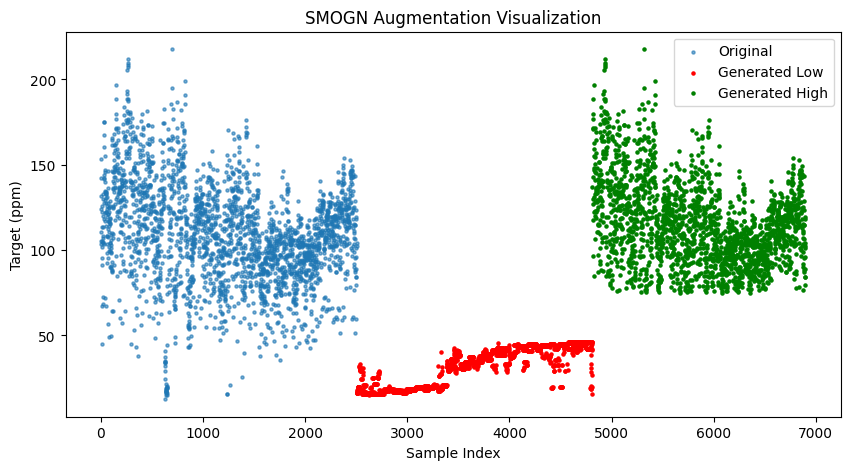

In [ ]:
X_new, target= dual_tail_smogn(
    X_new, target,
    target_col='target',
    low_thresh=75,
    high_thresh=165,
    rel_thres=0.95,
    k=3
)

In [ ]:
len(X_new)

low_mask  = target < 75
high_mask = target > 165
mid_mask  = (~low_mask) & (~high_mask)

print("Low extremes:", low_mask.sum())
print("Mid range:", mid_mask.sum())
print("High extremes:", high_mask.sum())

Low extremes: 2598
Mid range: 4118
High extremes: 183


In [ ]:
import pandas as pd

# Masks
low_mask  = target < 75
high_mask = target > 165
mid_mask  = (~low_mask) & (~high_mask)

# Split
df = X_new.copy()
df['target'] = target

df_low  = df[low_mask]
df_mid  = df[mid_mask]
df_high = df[high_mask]

# Target sizes (adjust if needed)
low_n = 500
mid_n = 700

# Downsample
df_low_down = df_low.sample(n=low_n, random_state=42)
df_mid_down = df_mid.sample(n=mid_n, random_state=42)

# Keep all high (important)
df_balanced = pd.concat([df_low_down, df_mid_down, df_high], ignore_index=True)

# Split back
target_bal = df_balanced['target']
X_bal = df_balanced.drop(columns=['target'])

# Check
print("Low:", (target_bal < 75).sum())
print("Mid:", ((target_bal >= 75) & (target_bal <= 165)).sum())
print("High:", (target_bal > 165).sum())

Low: 500
Mid: 700
High: 183


 Here number of estimators are = 200

In [ ]:
# @title
# id_feat_new, corr_val= select_by_correlation(X_new, target, threshold=0.2)
dict_results= mahalanobis_local_model_progress(
    id_feat_new, target,
    model_type="xgb",   # "rf" or "xgb"
    test_size=0.2,
    random_state=42,
    k_neighbors=500     # reduce for speed
)

Original columns: 180
Selected columns (|corr| > 0.2): 66


Here number of estimators are = 400, Paper Method


Running XGB on 501 test samples...

[1/501] | Actual: 107.318 | Pred: 102.083 | Error: 5.236 | Running MAE: 5.236
[2/501] | Actual: 191.529 | Pred: 171.319 | Error: 20.211 | Running MAE: 12.723
[3/501] | Actual: 128.115 | Pred: 133.272 | Error: 5.157 | Running MAE: 10.201
[4/501] | Actual: 131.127 | Pred: 134.869 | Error: 3.742 | Running MAE: 8.586
[5/501] | Actual: 120.929 | Pred: 98.842 | Error: 22.087 | Running MAE: 11.286
[6/501] | Actual: 96.180 | Pred: 88.463 | Error: 7.717 | Running MAE: 10.691
[7/501] | Actual: 55.223 | Pred: 85.103 | Error: 29.880 | Running MAE: 13.433
[8/501] | Actual: 85.713 | Pred: 89.967 | Error: 4.254 | Running MAE: 12.285
[9/501] | Actual: 167.089 | Pred: 171.916 | Error: 4.827 | Running MAE: 11.457
[10/501] | Actual: 85.006 | Pred: 103.036 | Error: 18.030 | Running MAE: 12.114
[11/501] | Actual: 122.455 | Pred: 106.314 | Error: 16.141 | Running MAE: 12.480
[12/501] | Actual: 145.758 | Pred: 148.241 | Error: 2.484 | Running MAE: 11.647
[13/501] | Actual

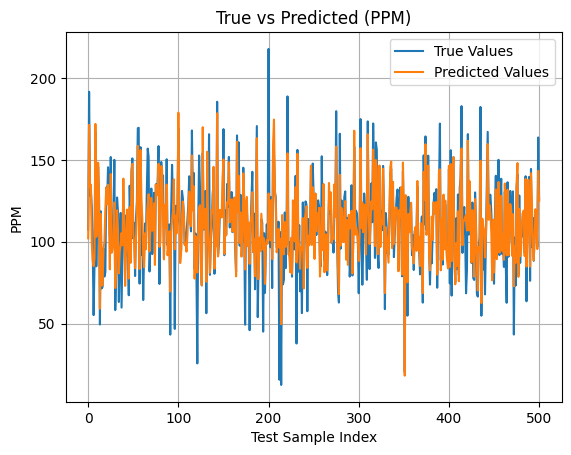

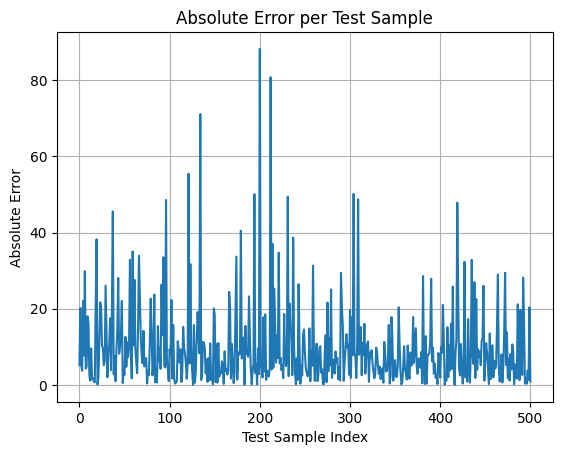

In [ ]:
# @title
# id_feat_new, corr_val= select_by_correlation(id_feat_new, target, threshold=0.2)
dict_results= mahalanobis_local_model_progress(
    X_new, target,
    model_type="xgb",   # "rf" or "xgb"
    test_size=0.2,
    random_state=42,
    k_neighbors=1000     # reduce for speed
)

XGB_Pipeline

MAE  : 0.9190339744543978
RMSE : 1.8874795776520155
MAPE : 1.79%
R2   : 0.998151894520608


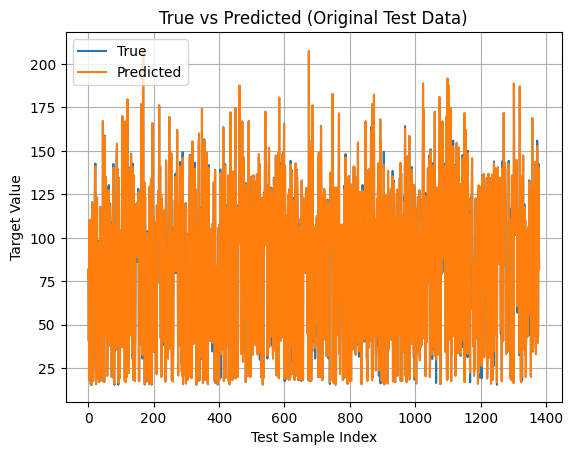

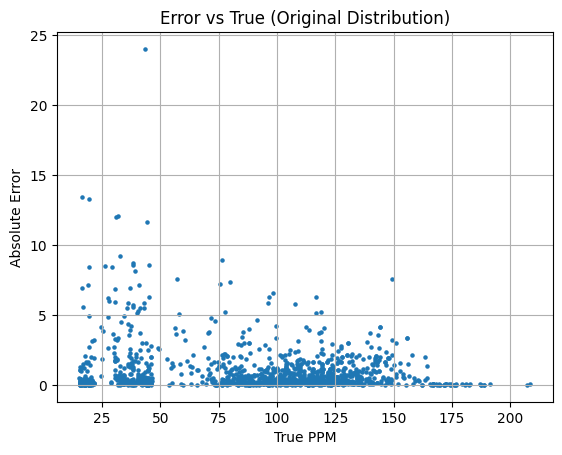

In [ ]:
results_dict= soft_cluster_pipeline_dual_data(X_bal, target_bal, X_new, target)

In [ ]:
# @title
import pickle
import numpy as np

# 🔹 Save models + GMM
with open("models_and_gmm.pkl", "wb") as f:
    pickle.dump({
        "models": results_dict["models"],
        "gmm": results_dict["gmm"]
    }, f)

# 🔹 Save predictions & errors
np.savez("results_arrays.npz",
         y_pred=results_dict["y_pred"],
         y_true=results_dict["y_true"],
         errors=results_dict["errors"])

# 🔹 Save metrics (simple text)
with open("metrics.txt", "w") as f:
    f.write(f"MAE: {results_dict['MAE']}\n")
    f.write(f"RMSE: {results_dict['RMSE']}\n")

Same Pipeline with xgb, but inputs to the function also include hyperparametres

In [ ]:
# @title
def soft_cluster_xgb_pipeline(
    X_df, y_df,
    n_clusters=3,
    test_size=0.2,
    random_state=42,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300
):

    from sklearn.model_selection import train_test_split
    from sklearn.mixture import GaussianMixture
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor
    import numpy as np

    # ---------------------------
    # Split
    # ---------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_df, test_size=test_size, random_state=random_state
    )

    X_train = np.array(X_train)
    X_test  = np.array(X_test)

    y_train = y_train.values.ravel()
    y_test  = y_test.values.ravel()

    # ---------------------------
    # GMM
    # ---------------------------
    gmm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gmm.fit(X_train)

    train_membership = gmm.predict_proba(X_train)

    # ---------------------------
    # Train models
    # ---------------------------
    models = {}

    for k in range(n_clusters):
        weights = train_membership[:, k]

        model = XGBRegressor(
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            n_jobs=-1
        )

        model.fit(X_train, y_train, sample_weight=weights)
        models[k] = model

    # ---------------------------
    # Predict
    # ---------------------------
    test_membership = gmm.predict_proba(X_test)

    y_pred = []

    for i in range(X_test.shape[0]):
        x = X_test[i].reshape(1, -1)
        weights = test_membership[i]

        preds = [models[k].predict(x)[0] for k in range(n_clusters)]
        y_pred.append(np.dot(weights, preds))

    y_pred = np.array(y_pred)

    # ---------------------------
    # Metrics
    # ---------------------------
    mae = mean_absolute_error(y_test, y_pred)

    return mae

Grid_Search for minimising MAE the most

In [ ]:
# @title
def grid_search_moe_xgb(X_df, y_df):

    max_depth_list = [3, 4, 5]
    learning_rate_list = [0.03, 0.05, 0.07]
    n_estimators_list = [200, 300, 400]

    results = []

    for md in max_depth_list:
        for lr in learning_rate_list:
            for ne in n_estimators_list:

                mae = soft_cluster_pipeline(
                    X_df, y_df,
                    md=md,
                    lr=lr,
                    ne=ne
                )

                print(f"depth={md}, lr={lr}, estimators={ne} → MAE={mae['MAE']:.4f}")

                results.append({
                    "max_depth": md,
                    "learning_rate": lr,
                    "n_estimators": ne,
                    "MAE": mae['MAE']
                })

    # Convert to DataFrame
    import pandas as pd
    results_df = pd.DataFrame(results)

    # Sort best first
    results_df = results_df.sort_values(by="MAE")

    print("\n🔥 Best Combination:")
    print(results_df.head(1))

    return results_df

In [ ]:
resukts_df= grid_search_moe_xgb(X_bal, target_bal)

NameError: name 'soft_cluster_pipeline' is not defined

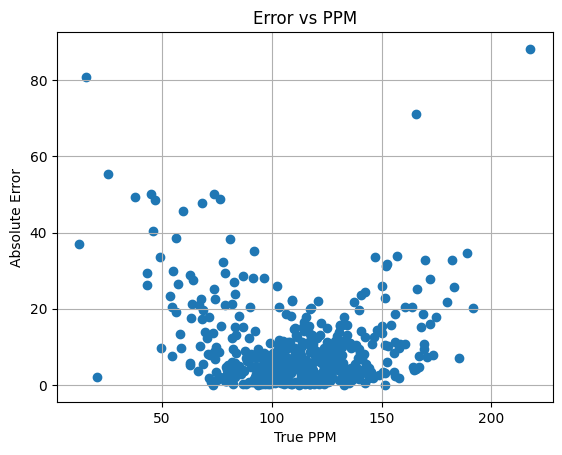

In [ ]:
y_true= (pd.read_csv('/content/df_results_local_models.csv'))['y_true']
errors= (pd.read_csv('/content/df_results_local_models.csv'))['errors']

plt.scatter(y_true, errors)
plt.xlabel("True PPM")
plt.ylabel("Absolute Error")
plt.title("Error vs PPM")
plt.grid()
plt.show()